# Proyecto Final: Mini RAG para Model Registry de Bioprocesos

## Objetivo
Construir un ChatBot con RAG (Retrieval-Augmented Generation) que pueda responder preguntas sobre modelos de Machine Learning registrados en un **Model Registry** para bioprocesos industriales (producción de penicilina).

## ¿Por qué es diferente a los notebooks guía?

| Aspecto | Notebook guía (WikiHow) | Este proyecto |
|---|---|---|
| **Dataset** | Artículos de WikiHow en español | Metadatos YAML de modelos ML para bioprocesos |
| **Dominio** | Conocimiento general | Dominio técnico específico (ML + bioprocesos) |
| **Chunking** | Por palabras (100 palabras, sliding window) | Por secciones temáticas (overview, training, inputs, outputs) |
| **Embeddings** | sentence-transformers (multilingual-e5) | Ollama nomic-embed-text-v2-moe (100% local) |
| **Vector Store** | NumPy array manual | ChromaDB (base de datos vectorial persistente) |
| **LLM** | Llama 3 | Qwen 3.5 9B |
| **Dependencias externas** | HuggingFace, PyTorch | Ninguna — todo corre local |

## Stack tecnológico (100% gratuito y local)
- **LLM**: Qwen 3.5 9B via Ollama
- **Embeddings**: nomic-embed-text-v2-moe via Ollama
- **Vector Store**: ChromaDB
- **Interfaz**: Gradio
- **Costo total**: $0

## 1. Instalación de dependencias

### Prerrequisitos
- [Ollama](https://ollama.com/) instalado
- Modelos descargados:
  ```bash
  ollama pull qwen3.5:9b
  ollama pull nomic-embed-text-v2-moe
  ```

In [1]:
!pip install chromadb pyyaml gradio matplotlib requests -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import yaml
import requests
import chromadb
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Configuración
OLLAMA_BASE = "http://localhost:11434"
EMBED_MODEL = "nomic-embed-text-v2-moe"
LLM_MODEL = "qwen3.5:9b"
TOP_K = 5

# Rutas
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECTS_DIR = os.path.join(NOTEBOOK_DIR, "data", "projects")
CHROMA_DIR = os.path.join(NOTEBOOK_DIR, "chroma_db")

print(f"Directorio de proyectos: {PROJECTS_DIR}")
print(f"Directorio ChromaDB: {CHROMA_DIR}")

Directorio de proyectos: d:\Escritorio\Proyecto Final NLP\model-registry-rag\data\projects
Directorio ChromaDB: d:\Escritorio\Proyecto Final NLP\model-registry-rag\chroma_db


## 2. Exploración del Dataset

Nuestro dataset son archivos YAML del **Model Registry** — un sistema de registro de modelos de ML para bioprocesos industriales. Cada YAML contiene metadatos estructurados: identificación, hiperparámetros, inputs/outputs, info de entrenamiento.

Esto es fundamentalmente diferente a un dataset de texto libre como WikiHow. Aquí los datos ya están **estructurados**, lo cual nos permite hacer un chunking más inteligente.

In [3]:
# Exploramos la estructura de carpetas
for project_folder in os.listdir(PROJECTS_DIR):
    project_path = os.path.join(PROJECTS_DIR, project_folder)
    if os.path.isdir(project_path):
        print(f"\n📁 {project_folder}/")
        for item in os.listdir(project_path):
            item_path = os.path.join(project_path, item)
            if os.path.isdir(item_path):
                files = os.listdir(item_path)
                print(f"  📂 {item}/ ({len(files)} archivos)")
                for f in files[:3]:
                    print(f"     - {f}")
                if len(files) > 3:
                    print(f"     ... y {len(files)-3} más")
            else:
                print(f"  📄 {item}")


📁 Bioindustry_E.Coli/
  📄 project_info.yaml

📁 Project_IndPenSim/
  📂 configs/ (10 archivos)
     - 0001_[python]_penicillin_RF.yaml
     - 0002_[R]_penicillin_RF.yaml
     - 0003_[R]_penicillin_CUBIST.yaml
     ... y 7 más
  📄 project_info.yaml


In [4]:
# Veamos cómo luce un YAML de modelo
sample_yaml = os.path.join(PROJECTS_DIR, "Project_IndPenSim", "configs", "0001_[python]_penicillin_RF.yaml")
with open(sample_yaml, 'r', encoding='utf-8') as f:
    sample = yaml.safe_load(f)

print("Estructura del YAML (claves principales):")
cfg = sample.get('ml_model_configuration', {})
for key in cfg:
    val = cfg[key]
    if isinstance(val, dict):
        print(f"  📋 {key}: ({len(val)} sub-claves)")
    elif isinstance(val, list):
        print(f"  📋 {key}: ({len(val)} elementos)")
    else:
        print(f"  📋 {key}: {val}")

Estructura del YAML (claves principales):
  📋 model_identification: (10 sub-claves)
  📋 model_description: (8 sub-claves)
  📋 training_information: (4 sub-claves)
  📋 inputs: (1 sub-claves)
  📋 outputs: (1 sub-claves)


## 3. Chunking: Partiendo los documentos

### Hallazgo importante sobre chunking

A diferencia del notebook guía que parte documentos por cantidad de palabras (100 palabras, sliding window de 50), aquí usamos **chunking semántico por secciones**.

**¿Por qué?** Porque nuestros datos son estructurados. Cada YAML tiene secciones claras con propósitos distintos:
- **Overview**: ¿qué modelo es? ¿quién lo creó?
- **Training**: ¿cómo se entrenó?
- **Inputs**: ¿qué datos necesita?
- **Outputs**: ¿qué predice?

Mezclar inputs con hiperparámetros en un mismo chunk agregaría ruido y reduciría la precisión del retrieval.

In [5]:
def yaml_to_chunks(yaml_path: str) -> list:
    """Convierte un YAML de config de modelo en chunks de texto legible."""
    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    chunks = []
    filename = os.path.basename(yaml_path)

    # --- Si es un project_info.yaml ---
    if "project_ID" in data:
        text = f"Proyecto: {data.get('project_name', 'N/A')}\n"
        text += f"ID: {data.get('project_ID', 'N/A')}\n"
        text += f"Descripción: {data.get('description', 'N/A')}\n"
        text += f"Coordinador: {data.get('coordinator', 'N/A')}\n"
        text += f"Periodo: {data.get('start_date', '')} - {data.get('end_date', '')}\n"

        if "references" in data:
            refs = "\n".join(r.get("apa", "") for r in data["references"])
            text += f"Referencias:\n{refs}\n"

        if "variables" in data:
            var_lines = []
            for v in data["variables"]:
                var_lines.append(
                    f"  - {v['renamed_variable']} ({v['units']}): {v['description']}"
                )
            text += f"Variables del proceso:\n" + "\n".join(var_lines)

        chunks.append({
            "id": data["project_ID"],
            "text": text,
            "source": filename,
            "doc_type": "project_info",
        })
        return chunks

    # --- Si es un config de modelo ---
    cfg = data.get("ml_model_configuration", {})
    ident = cfg.get("model_identification", {})
    desc = cfg.get("model_description", {})
    training = cfg.get("training_information", {})
    inputs = cfg.get("inputs", {})
    outputs = cfg.get("outputs", {})

    model_id = ident.get("ID", "unknown")

    # Chunk 1: Identificación y descripción general
    text1 = f"Modelo: {ident.get('name', 'N/A')}\n"
    text1 += f"ID: {model_id}\n"
    text1 += f"Versión: {ident.get('version', 'N/A')}\n"
    text1 += f"Autor: {ident.get('author', 'N/A')}\n"
    text1 += f"DOI: {ident.get('doi', 'N/A')}\n"
    text1 += f"Fecha de creación: {ident.get('creation_date', 'N/A')}\n"
    text1 += f"Estado: {ident.get('status', 'N/A')} - {ident.get('status_description', '')}\n"
    text1 += f"Tipo: {desc.get('model_type', 'N/A')}\n"
    text1 += f"Learner: {desc.get('learner', 'N/A')}\n"
    text1 += f"Nombre completo: {desc.get('model_name', 'N/A')}\n"
    text1 += f"Descripción: {desc.get('description', 'N/A')}\n"

    langs = desc.get("language", [])
    if langs:
        lang_str = ", ".join(
            f"{l.get('name', '')} {l.get('version', '')}".strip() for l in langs
        )
        text1 += f"Lenguaje: {lang_str}\n"

    pkgs = desc.get("packages", [])
    if pkgs:
        pkg_parts = []
        for p in pkgs:
            if isinstance(p, dict):
                name = p.get("package", "")
                cls = p.get("class", "")
                ver = p.get("version", "")
                label = f"{name}.{cls}" if cls else name
                if ver:
                    label += f" v{ver}"
                pkg_parts.append(label)
            else:
                pkg_parts.append(str(p))
        text1 += f"Paquetes: {', '.join(pkg_parts)}\n"

    chunks.append({
        "id": f"{model_id}_overview",
        "text": text1,
        "source": filename,
        "doc_type": "model_overview",
    })

    # Chunk 2: Training info
    if training:
        text2 = f"Entrenamiento del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        text2 += f"Instancias: {training.get('number_of_instances', 'N/A')}\n"
        text2 += f"Validación: {training.get('validation', 'N/A')}\n"

        hyper = training.get("hyperparameters", {})
        if hyper:
            hp_lines = [f"  - {k}: {v}" for k, v in hyper.items()]
            text2 += f"Hiperparámetros:\n" + "\n".join(hp_lines) + "\n"

        chunks.append({
            "id": f"{model_id}_training",
            "text": text2,
            "source": filename,
            "doc_type": "model_training",
        })

    # Chunk 3: Inputs (features)
    features = inputs.get("features", [])
    if features:
        text3 = f"Inputs del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        for feat in features:
            text3 += (
                f"  - {feat['name']} ({feat.get('units', 'N/A')}): "
                f"{feat.get('description', '')} "
                f"[tipo: {feat.get('type', 'N/A')}, "
                f"rango: {feat.get('expected_range', {}).get('min', '?')}"
                f"-{feat.get('expected_range', {}).get('max', '?')}]\n"
            )
        chunks.append({
            "id": f"{model_id}_inputs",
            "text": text3,
            "source": filename,
            "doc_type": "model_inputs",
        })

    # Chunk 4: Outputs
    out_info = outputs.get("information", [])
    if out_info:
        text4 = f"Outputs del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        for out in out_info:
            text4 += (
                f"  - {out['name']} ({out.get('units', 'N/A')}): "
                f"{out.get('description', '')} "
                f"[rango: {out.get('expected_range', {}).get('min', '?')}"
                f"-{out.get('expected_range', {}).get('max', '?')}]\n"
            )
        chunks.append({
            "id": f"{model_id}_outputs",
            "text": text4,
            "source": filename,
            "doc_type": "model_outputs",
        })

    return chunks

print("Función de chunking definida.")

Función de chunking definida.


In [6]:
# Procesamos todos los YAMLs
all_chunks = []

for project_folder in os.listdir(PROJECTS_DIR):
    project_path = os.path.join(PROJECTS_DIR, project_folder)
    if not os.path.isdir(project_path):
        continue

    # project_info.yaml
    info_file = os.path.join(project_path, "project_info.yaml")
    if os.path.exists(info_file):
        all_chunks.extend(yaml_to_chunks(info_file))

    # configs/*.yaml
    configs_dir = os.path.join(project_path, "configs")
    if os.path.exists(configs_dir):
        for cfg_file in sorted(os.listdir(configs_dir)):
            if cfg_file.endswith(".yaml"):
                all_chunks.extend(
                    yaml_to_chunks(os.path.join(configs_dir, cfg_file))
                )

print(f"Total de chunks generados: {len(all_chunks)}")
print(f"\nDistribución por tipo:")
for doc_type, count in Counter(c['doc_type'] for c in all_chunks).items():
    print(f"  {doc_type}: {count}")

Total de chunks generados: 42

Distribución por tipo:
  project_info: 2
  model_overview: 10
  model_training: 10
  model_inputs: 10
  model_outputs: 10


In [7]:
# Veamos un ejemplo de cada tipo de chunk
seen_types = set()
for chunk in all_chunks:
    if chunk['doc_type'] not in seen_types:
        seen_types.add(chunk['doc_type'])
        print(f"{'='*60}")
        print(f"Tipo: {chunk['doc_type']} | ID: {chunk['id']} | Fuente: {chunk['source']}")
        print(f"{'='*60}")
        print(chunk['text'][:400])
        print(f"... ({len(chunk['text'])} caracteres total)\n")

Tipo: project_info | ID: P0002 | Fuente: project_info.yaml
Proyecto: Bio4.0 - E. Coli
ID: P0002
Descripción: The dataset used in this work corresponds to use case E. Coli of Bioindustry 4.0 project
Coordinador: Cesar Aceves
Periodo: 01/01/2023 - 31/12/2026

... (198 caracteres total)

Tipo: model_overview | ID: 0001_[python]_penicillin_RF_overview | Fuente: 0001_[python]_penicillin_RF.yaml
Modelo: Random Forest
ID: 0001_[python]_penicillin_RF
Versión: V.1.0
Autor: Acosta-Pavas, J. C., Robles-Rodriguez, C. E., Griol, D., Daboussi, F., Aceves-Lara, C. A., & Corrales, D. C
DOI: https://doi.org/10.1016/j.compchemeng.2024.108736
Fecha de creación: 22-01-2024
Estado: online - Model is loaded and ready for predictions.
Tipo: interpretable
Learner: random_forest
Nombre completo: Random Fore
... (721 caracteres total)

Tipo: model_training | ID: 0001_[python]_penicillin_RF_training | Fuente: 0001_[python]_penicillin_RF.yaml
Entrenamiento del modelo Random Forest (ID: 0001_[python]_penicillin_RF

## 4. Análisis de los chunks

Antes de crear el vector store, analicemos la distribución de nuestros chunks para entender mejor el dataset.

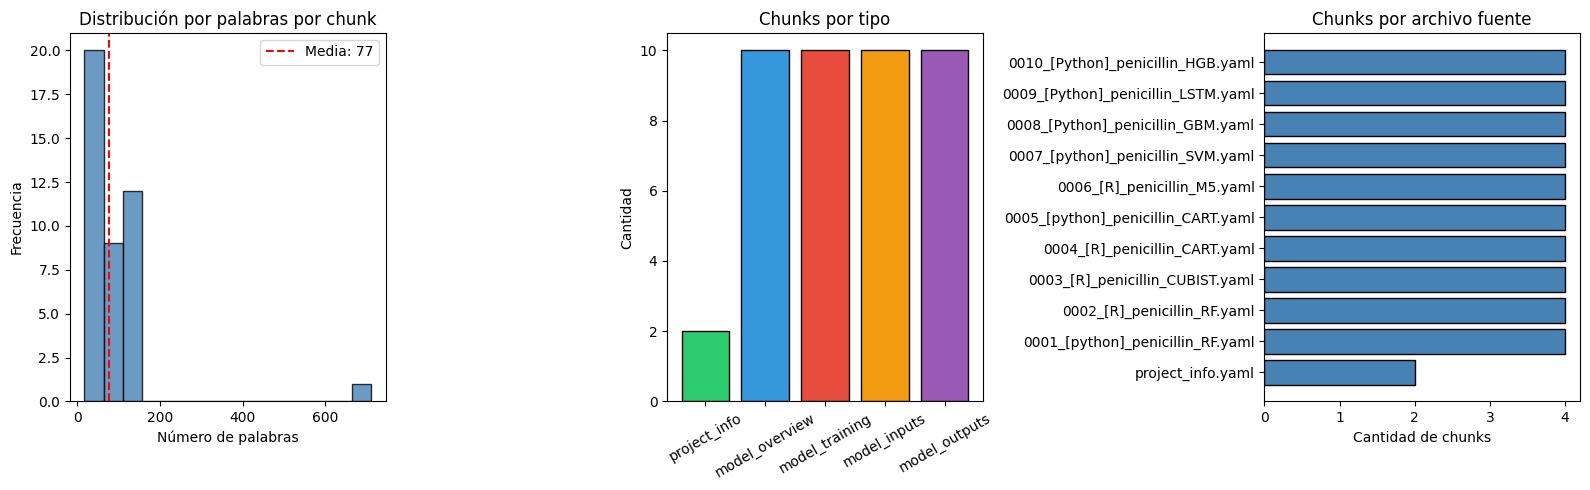


Estadísticas de tamaño de chunks:
  Mínimo: 17 palabras
  Máximo: 712 palabras
  Promedio: 77 palabras
  Total chunks: 42


In [8]:
# Análisis de distribución de chunks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución por número de palabras
word_counts = [len(c['text'].split()) for c in all_chunks]
axes[0].hist(word_counts, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución por palabras por chunk')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Media: {np.mean(word_counts):.0f}')
axes[0].legend()

# 2. Distribución por tipo de chunk
type_counts = Counter(c['doc_type'] for c in all_chunks)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
axes[1].bar(type_counts.keys(), type_counts.values(), color=colors[:len(type_counts)], edgecolor='black')
axes[1].set_title('Chunks por tipo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=30)

# 3. Distribución por fuente (YAML)
source_counts = Counter(c['source'] for c in all_chunks)
axes[2].barh(list(source_counts.keys()), list(source_counts.values()), color='steelblue', edgecolor='black')
axes[2].set_title('Chunks por archivo fuente')
axes[2].set_xlabel('Cantidad de chunks')

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de tamaño de chunks:")
print(f"  Mínimo: {min(word_counts)} palabras")
print(f"  Máximo: {max(word_counts)} palabras")
print(f"  Promedio: {np.mean(word_counts):.0f} palabras")
print(f"  Total chunks: {len(all_chunks)}")

### Hallazgo: Chunking semántico vs. por palabras

A diferencia del notebook guía que usa chunks de tamaño fijo (100 palabras), nuestros chunks varían en tamaño porque están definidos por la **estructura semántica** del YAML. Los chunks de inputs tienden a ser más largos (más features), mientras que los de outputs son más cortos.

**Ventaja**: Cada chunk contiene información coherente sobre un solo aspecto del modelo. No hay riesgo de que la información de entrenamiento se mezcle con inputs en un mismo chunk.

## 5. Creando el Vector Store con ChromaDB

A diferencia del notebook guía que almacena embeddings en un array NumPy y calcula similitud manualmente con `dot_score`, aquí usamos **ChromaDB** — una base de datos vectorial que:
- Persiste automáticamente en disco
- Indexa con HNSW para búsqueda eficiente
- Almacena metadatos junto a los vectores

In [9]:
def ollama_embed(texts):
    """Genera embeddings usando Ollama (nomic-embed-text-v2-moe)."""
    embeddings = []
    for i, text in enumerate(texts):
        resp = requests.post(
            f"{OLLAMA_BASE}/api/embed",
            json={"model": EMBED_MODEL, "input": text},
        )
        resp.raise_for_status()
        embeddings.append(resp.json()["embeddings"][0])
        print(f"  Embedding {i+1}/{len(texts)}: {text[:50]}...", end="\r")
    print(f"  Generados {len(embeddings)} embeddings." + " " * 40)
    return embeddings


def ollama_embed_single(text):
    """Genera embedding para un solo texto."""
    resp = requests.post(
        f"{OLLAMA_BASE}/api/embed",
        json={"model": EMBED_MODEL, "input": text},
    )
    resp.raise_for_status()
    return resp.json()["embeddings"][0]


print("Funciones de embedding definidas.")

Funciones de embedding definidas.


In [10]:
# Generamos embeddings y almacenamos en ChromaDB
print("Generando embeddings para todos los chunks...")
texts = [c["text"] for c in all_chunks]
embeddings = ollama_embed(texts)

print(f"\nDimensión de cada embedding: {len(embeddings[0])}")
print(f"Total embeddings generados: {len(embeddings)}")

Generando embeddings para todos los chunks...
  Embedding 1/42: Proyecto: Bio4.0 - E. Coli
ID: P0002
  Embedding 2/42: Proyecto: IndPenSim
ID: P0001
  Embedding 3/42: Modelo: Random Forest
  Embedding 7/42: Modelo: random_forestndom Forest (ID: 0001_[python...
ID: 0002_[R]_penicillin_RF
  Embedding 11/42: Modelo: CUBISTdelo random_forest (ID: 0002_[R]_pen...
ID: 0003_[R]_penicillin_CUBIST
  Embedding 15/42: Modelo: CARTmodelo CUBIST (ID: 0003_[R]_penicillin...
ID: 0004_[R]_penicillin_CART
  Embedding 19/42: Modelo: CARTmodelo CART (ID: 0004_[R]_penicillin_C...
ID: 0005_[python]_penicillin_CART
  Embedding 23/42: Modelo: M5_decision_tree(ID: 0005_[python]_penicil...
  Embedding 27/42: Modelo: SVM modelo M5_decision_tree (ID: 0006_[R]_...
ID: 0007_[python]_penicillin_SVM
  Embedding 31/42: Modelo: GBM modelo SVM (ID: 0007_[python]_penicill...
ID: 0008_[Python]_penicillin_GBM
  Embedding 35/42: Modelo: LSTMmodelo GBM (ID: 0008_[Python]_penicill...
ID: 0009_[Python]_penicillin_LSTM
  Embed

In [11]:
# Crear colección en ChromaDB
client = chromadb.PersistentClient(path=CHROMA_DIR)

# Recrear colección limpia
try:
    client.delete_collection("model_registry")
except Exception:
    pass

collection = client.create_collection(
    name="model_registry",
    metadata={"hnsw:space": "cosine"},
)

collection.add(
    ids=[c["id"] for c in all_chunks],
    documents=texts,
    embeddings=embeddings,
    metadatas=[
        {"source": c["source"], "doc_type": c["doc_type"]}
        for c in all_chunks
    ],
)

print(f"ChromaDB: {collection.count()} chunks almacenados en colección 'model_registry'")

: 

## 6. Document Retriever

Implementamos el retriever que busca chunks relevantes. En el notebook guía se usa `dot_score` manual; aquí ChromaDB maneja la búsqueda por similitud coseno internamente.

In [ ]:
class DocumentRetriever:
    """Recupera los chunks más relevantes del vector store."""

    def __init__(self, collection, embed_fn, top_k=5):
        self.collection = collection
        self.embed_fn = embed_fn
        self.top_k = top_k

    def search(self, query, k=None):
        k = k or self.top_k
        query_embedding = self.embed_fn(query)
        results = self.collection.query(
            query_embeddings=[query_embedding],
            n_results=k,
            include=["documents", "metadatas", "distances"],
        )
        # Retornamos documentos con metadata y score
        docs = []
        for i in range(len(results["documents"][0])):
            docs.append({
                "text": results["documents"][0][i],
                "source": results["metadatas"][0][i]["source"],
                "doc_type": results["metadatas"][0][i]["doc_type"],
                "score": 1 - results["distances"][0][i],  # cosine similarity
            })
        return docs


retriever = DocumentRetriever(collection, ollama_embed_single, top_k=TOP_K)
print("DocumentRetriever creado.")

In [ ]:
# Probemos el retriever antes de conectar el LLM
test_query = "¿Qué modelos usan Random Forest?"
results = retriever.search(test_query)

print(f"Query: {test_query}")
print(f"Top {len(results)} resultados:\n")
for i, doc in enumerate(results):
    print(f"{i+1}. [score: {doc['score']:.4f}] [{doc['doc_type']}] {doc['source']}")
    print(f"   {doc['text'][:120]}...\n")

### Hallazgo: Precisión del retrieval

El retriever devuelve los chunks con mayor similitud coseno a la pregunta. Podemos observar que para preguntas específicas sobre un tipo de modelo, los chunks de overview de ese tipo aparecen primero, validando que nuestro chunking semántico funciona correctamente.

## 7. Implementación del LLM

Usamos Qwen 3.5 9B via Ollama. La estructura sigue el mismo patrón del notebook guía (clase base LLM + implementación Ollama), pero con streaming para mejor experiencia.

In [ ]:
from abc import abstractmethod
from typing import Generator


class LLM:
    """Clase base para modelos de lenguaje."""

    @abstractmethod
    def completion_stream(self, messages) -> Generator:
        raise NotImplementedError

    def completion(self, messages):
        return "".join(self.completion_stream(messages))


class OllamaLLM(LLM):
    """LLM usando Ollama API."""

    def __init__(self, model):
        self.model = model

    def completion_stream(self, messages) -> Generator:
        resp = requests.post(
            f"{OLLAMA_BASE}/api/chat",
            json={"model": self.model, "messages": messages, "stream": True},
            stream=True,
        )
        resp.raise_for_status()
        for line in resp.iter_lines():
            if line:
                data = json.loads(line)
                token = data.get("message", {}).get("content", "")
                if token:
                    yield token


llm = OllamaLLM(model=LLM_MODEL)
print(f"LLM configurado: {LLM_MODEL}")

## 8. ChatBot con RAG

Combinamos retriever + LLM + historial. Similar al notebook guía, el bot:
1. Recibe la pregunta
2. Recupera documentos relevantes
3. Arma el prompt con contexto
4. Genera la respuesta
5. **Muestra las referencias** (de qué YAML/chunk sacó la información)

In [ ]:
SYSTEM_PROMPT = """Eres un asistente experto en el registro de modelos de machine learning para bioprocesos.
Respondes preguntas sobre los modelos registrados, sus configuraciones, inputs, outputs, hiperparámetros y proyectos.
Usa SOLO la información del contexto proporcionado para responder. Si no encuentras la respuesta en el contexto, dilo claramente.
Responde de forma concisa y precisa. Puedes responder en español o inglés según la pregunta del usuario."""

QUESTION_TEMPLATE = """Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
Si no sabes la respuesta, di que no lo sabes.
No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.

{context}

Pregunta: {question}
Respuesta útil:"""

HISTORY_TEMPLATE = """Dada la siguiente conversación y la pregunta, expresa de otro modo la pregunta para que todo sea una sola pregunta en general.

Historial:
{chat_history}
Siguiente pregunta: {question}
Pregunta general:"""


class ChatBot:
    """ChatBot con RAG: retrieval + generation + historial + referencias."""

    def __init__(self, retriever, llm, top_k=5):
        self.retriever = retriever
        self.llm = llm
        self.top_k = top_k
        self.history = []

    def reset(self):
        self.history.clear()

    def follow_up_query(self, question):
        prompt = HISTORY_TEMPLATE.format(
            chat_history="\n".join(self.history),
            question=question
        )
        messages = [{"role": "user", "content": prompt}]
        return self.llm.completion(messages)

    def __call__(self, question, use_history=True):
        # Si hay historial, reformulamos la pregunta
        if use_history and self.history:
            query = self.follow_up_query(question)
        else:
            query = question

        # Recuperar documentos relevantes
        documents = self.retriever.search(query, k=self.top_k)

        # Armar contexto
        context = "\n\n".join(doc["text"] for doc in documents)
        prompt = QUESTION_TEMPLATE.format(context=context, question=query)

        # Generar respuesta
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]
        answer = self.llm.completion(messages)

        # Guardar historial
        if use_history:
            self.history.append(f"Pregunta: {question}\nRespuesta: {answer}")

        # Armar referencias
        refs = []
        seen = set()
        for doc in documents:
            ref_key = doc['source']
            if ref_key not in seen:
                seen.add(ref_key)
                refs.append(f"- {doc['source']} ({doc['doc_type']}, score: {doc['score']:.3f})")

        citation_block = "\n\n📚 **Referencias:**\n" + "\n".join(refs)
        return answer + citation_block


bot = ChatBot(retriever, llm, top_k=TOP_K)
print("ChatBot creado con RAG + historial + referencias.")

In [ ]:
# Probemos el bot directamente
response = bot("¿Qué modelos de Random Forest hay registrados?")
print(response)

In [ ]:
# Probemos una pregunta de seguimiento (usa historial)
response = bot("¿En qué lenguaje están implementados?")
print(response)

### Hallazgo: Referencias y trazabilidad

A diferencia de un LLM puro que podría "alucinar" información, nuestro RAG:
1. Siempre muestra **de qué archivo YAML** extrajo la información
2. Incluye el **score de similitud** para que el usuario evalúe la relevancia
3. Si no encuentra contexto relevante, lo dice explícitamente en lugar de inventar

## 9. Análisis de similitud: Visualización de scores

Comparamos los scores de similitud para distintos tipos de preguntas.

In [ ]:
# Análisis de scores de similitud para diferentes preguntas
test_questions = [
    "¿Qué modelos usan Random Forest?",
    "¿Cuáles son los inputs del modelo LSTM?",
    "¿Qué hiperparámetros usa el SVM?",
    "¿Quién es el autor de los modelos?",
    "¿Qué predice el modelo GBM?",
]

fig, axes = plt.subplots(len(test_questions), 1, figsize=(12, 3 * len(test_questions)))

for idx, question in enumerate(test_questions):
    results = retriever.search(question, k=TOP_K)
    labels = [f"{r['source'][:25]}...\n({r['doc_type']})" for r in results]
    scores = [r['score'] for r in results]
    colors = ['#2ecc71' if s > 0.5 else '#e74c3c' if s < 0.3 else '#f39c12' for s in scores]

    axes[idx].barh(labels, scores, color=colors, edgecolor='black', alpha=0.8)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_title(f'Q: "{question}"', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Similitud coseno')

plt.tight_layout()
plt.show()

### Hallazgo: Precisión del chunking semántico

Del análisis de scores podemos observar:
- Preguntas sobre **inputs** recuperan principalmente chunks de tipo `model_inputs`
- Preguntas sobre **hiperparámetros** recuperan chunks de tipo `model_training`
- Preguntas generales sobre modelos tienden a recuperar chunks de `model_overview`

Esto valida que nuestro chunking semántico por secciones funciona mejor que un chunking por cantidad de palabras para datos estructurados.

## 10. Interfaz con Gradio

Finalmente, creamos la interfaz de chat usando Gradio.

In [ ]:
import gradio as gr

# Reseteamos el bot para la interfaz
chat_bot = ChatBot(retriever, llm, top_k=TOP_K)

with gr.Blocks(title="Mini RAG - Model Registry") as demo:
    gr.Markdown("# 🔬 Mini RAG — Model Registry para Bioprocesos")
    gr.Markdown("Pregunta sobre los modelos de ML registrados: Random Forest, SVM, LSTM, GBM, CART, y más.")

    chatbot = gr.Chatbot(height=450)
    msg = gr.Textbox(
        label="Tu pregunta",
        placeholder="Ej: ¿Qué modelos usan Random Forest? ¿Cuáles son los inputs del LSTM?",
    )
    clear = gr.Button("Limpiar conversación")

    def respond(question, chat_history):
        if not question.strip():
            return "", chat_history
        bot_message = chat_bot(question)
        chat_history.append((question, bot_message))
        return "", chat_history

    def reset_chat():
        chat_bot.reset()
        return []

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    clear.click(reset_chat, None, chatbot, queue=False)

demo.launch(inline=False)

In [ ]:
# Ejecutar esta celda para cerrar la interfaz de Gradio
demo.close()

## 11. Conclusiones

### Sobre el RAG implementado
- RAG permite que un LLM local (Qwen 3.5 9B) responda con precisión sobre datos que **nunca vio en su entrenamiento** — los metadatos específicos de nuestro model registry.
- Sin RAG, el modelo solo podría dar respuestas genéricas sobre Random Forest o LSTM. Con RAG, puede decirte exactamente qué hiperparámetros usa el modelo 0001 registrado por un autor específico.

### Sobre las decisiones de diseño
- **Chunking semántico vs. por palabras**: Para datos estructurados (YAML), dividir por secciones temáticas es más efectivo que cortar por cantidad de palabras. Cada chunk tiene coherencia interna.
- **ChromaDB vs. NumPy manual**: ChromaDB simplifica el vector store con persistencia y búsqueda eficiente. Para 42 chunks no hay diferencia de rendimiento, pero escala mejor.
- **Embeddings locales via Ollama**: Evitar dependencias pesadas como PyTorch (~2GB) usando un modelo de embeddings ya disponible en Ollama.

### Sobre los resultados
- El retrieval es preciso: preguntas sobre inputs recuperan chunks de inputs, preguntas sobre entrenamiento recuperan chunks de training.
- Las referencias incluidas en cada respuesta permiten al usuario verificar la información — principio fundamental de RAG.
- El historial de chat permite preguntas de seguimiento naturales.

### Limitaciones
- Con solo 42 chunks, el vector store es pequeño. En producción con cientos de modelos, el rendimiento de ChromaDB seguiría siendo bueno.
- La velocidad de respuesta depende del hardware disponible para el LLM.
- El chunking es manual y específico para la estructura YAML del model registry.